### Fera formidável 4.5 - Um momento, por favor!

#### Enunciado

Objetivo: implemente o otimizador de Descida do Gradiente com Momento (Gradient
Descent with Momentum) na rede neural feita em Python puro.

Comentário: observe que o enunciado diz claramente que é para realizar a tarefa na
rede neural feita em Python puro nos vídeos da disciplina. Se você está usando o PyTorch,
numpy, tensorflow, keras, lightning ou qualquer outra biblioteca pronta, você está no
caminho errado!

### Introdução

O otmizador de Descida do Gradiente com Momento tem o intuito de acelerar a convergência de uma rede neural por meio da atualização dos parâmetros na direção oposta ao gradiente de erro. Isso é feito a partir de uma variável velocidade que acumula as atualizações das épocas anteriores, logo, se a rede estiver indo em uma mesma direção essas velociades serão aumentadas tornando a convergência mais rápida. 

A fórmula para a atualização dos pesos utilizando a Descida do Gradiente com Momento é dada por:

$$
v_t = \gamma v_{t-1} + \alpha \cdot \nabla J(\theta _t)
$$

$$
\theta _t = \theta _{t-1} - v_t
$$

Onde:

$v_t$ é a velocidade 

$\gamma$ é o coeficiente de momento

$\alpha$ é a taxa de aprendizado

$\nabla J(\theta _t)$ é o gradiente da perda em relação aos parâmetros $\theta _{t-1} - v_t$

$\theta _t$ são os parâmetros

A alteração feita no código da rede neural em python puro foi realizada apenas no loop de treinamento do modelo, a partir da criação do dicionário `velocidades` que armazena a velocidade para cada parâmetro da MLP antes do modelo começar a ser treinado. Dentro do loop, no momento que os parâmetros são atualizados, eles são atualizados utilizando a fórmula para Descida do Gradiente com Momento atualiando as velocidades do dicionário `velocidades`.

### Importando bibliotecas

In [26]:
import time
import seaborn as sns
import matplotlib.pyplot as plt
from classes import Valor, Neuronio, Camada, MLP
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Definindo os datasets

In [27]:
df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [28]:
entradas = df.drop(columns= ["petal_width", "species"]).values
saidas = df["petal_width"].values.reshape(-1, 1)

### Dividindo os dados em treino e teste e aplicando a normalização padrão 

In [29]:
TAMANHO_TESTE = 0.1 

# Alocando 10% dos dados para teste
entradas_treino, entradas_teste, saidas_treino, saidas_teste = train_test_split(
    entradas, saidas, test_size=TAMANHO_TESTE)

In [30]:
normalizador = StandardScaler()
x_treino = normalizador.fit_transform(entradas_treino).tolist()
x_teste = normalizador.transform(entradas_teste).tolist()

saidas_treino_norm = normalizador.fit_transform(saidas_treino).tolist()
saidas_teste_norm = normalizador.transform(saidas_teste).tolist()

y_true = [j for i in saidas_treino_norm for j in i]
y_teste = [j for i in saidas_teste_norm for j in i]

In [31]:
x_treino

[[1.0389171008359372, -1.2314666565566181, 1.1827094278892083],
 [0.32394441461919266, -1.0089124415162647, 1.0692701577186623],
 [-1.3443251865532093, 0.326412848725855, -1.199515245692253],
 [0.08562018588027884, 0.326412848725855, 0.6155130770364794],
 [0.5622686433581074, -1.676575086637325, 0.38863453669538806],
 [0.5622686433581074, 0.5489670637662074, 1.296148698059754],
 [-1.4634873009226672, 0.10385863368550156, -1.256234880777526],
 [-0.152704042858636, -0.11869558135485188, 0.27519526652484216],
 [0.8005928720970223, -0.5638040114355588, 0.5020738068659335],
 [-0.03354192848917912, 2.1068465690486806, -1.4263937860333449],
 [0.5622686433581074, 0.5489670637662074, 0.5587934419512066],
 [-0.271866157228094, -0.11869558135485188, 0.21847563143956897],
 [0.6814307577275655, 0.10385863368550156, 1.0125505226333897],
 [-0.152704042858636, -0.5638040114355588, 0.21847563143956897],
 [-1.1060009578142944, -1.2314666565566181, 0.4453541717806608],
 [-1.701811529661581, -0.3412497963

### Treinando a MLP

In [32]:
NUM_DADOS_DE_ENTRADA = 3  
NUM_DADOS_DE_SAIDA = 1    
CAMADAS_OCULTAS = [3, 2]  

arquitetura_da_rede = CAMADAS_OCULTAS + [NUM_DADOS_DE_SAIDA]

minha_mlp = MLP(NUM_DADOS_DE_ENTRADA, arquitetura_da_rede)

In [33]:
NUM_EPOCAS = 300
TAXA_DE_APRENDIZADO = 0.001 # Resultado melhor do que 0.01
COEFICIENTE_DE_MOMENTO = 0.9

inicio = time.time()

velocidades = {} # Fera 4.5
for p in minha_mlp.parametros():
    velocidades[p] = 0
    
print(velocidades)
    
x_plot = []
y_plot = []

for epoca in range(NUM_EPOCAS):
    # forward pass
    y_pred = []
    for exemplo in x_treino:
        previsao = minha_mlp(exemplo, treino=True)
        y_pred.append(previsao)

    # loss
    erros = []
    for yt, yp in zip(y_true, y_pred):
        residuo = yp - yt
        erro_quadratico = residuo ** 2
        erros.append(erro_quadratico)        
    loss = sum(erros)

    # zero grad
    for p in minha_mlp.parametros():
        p.grad = 0

    # backpropagation
    loss.propagar_tudo()

    # atualiza parâmetros
    for p in minha_mlp.parametros(): 
        vel = velocidades[p] # Fera 4.5
        vel = COEFICIENTE_DE_MOMENTO * vel + TAXA_DE_APRENDIZADO * p.grad 
        p.data -= vel
        velocidades[p] = vel

    # Validação
    #y_val_pred = [minha_mlp(x, treino = False) for x in x_teste] # Fera 4.3
        
    #erros_val = [(yp - yt)**2 for yp, yt in zip(y_val_pred, y_val)]
    #loss_val = sum(erros_val)
    
    # mostra resultado (opcional)
    print(f"Época {epoca + 1:03d} — Perda Treino: {loss.data}")
    
    x_plot.append(epoca)
    y_plot.append(loss.data)
    
print(velocidades)
fim = time.time()
tempo = fim - inicio
print()
print(f"O código demorou {tempo/60:.2f} minutos para rodar")

{Valor(data=0.21354665753600255): 0, Valor(data=-0.44808311088484976): 0, Valor(data=0.4356002731301931): 0, Valor(data=-0.10417981281497934): 0, Valor(data=-0.7201288152389349): 0, Valor(data=-0.5191086424881108): 0, Valor(data=0.5812804689924567): 0, Valor(data=0.5249389086823513): 0, Valor(data=-0.44692628074910834): 0, Valor(data=-0.8021125856922517): 0, Valor(data=-0.05210256470104291): 0, Valor(data=-0.9259672821565421): 0, Valor(data=0.22954593257667044): 0, Valor(data=0.188473931934519): 0, Valor(data=0.20220336044566323): 0, Valor(data=-0.9416793532062799): 0, Valor(data=-0.9752966191889034): 0, Valor(data=-0.3844533904243921): 0, Valor(data=-0.6893547404566311): 0, Valor(data=0.5767573843896618): 0, Valor(data=0.6050962399171211): 0, Valor(data=0.2616238062536502): 0, Valor(data=-0.8713789278475157): 0}
Época 001 — Perda Treino: 153.27225471571163
Época 002 — Perda Treino: 152.54278787237624
Época 003 — Perda Treino: 151.23357546551114
Época 004 — Perda Treino: 149.5320223857

In [35]:
velocidades

{Valor(data=0.8340795049164015): 0.012230443133690339,
 Valor(data=0.6104951853405501): 0.0013127367492129962,
 Valor(data=2.1920821160202006): -0.0036456124275243596,
 Valor(data=-0.9763503709168914): 0.003897419125722146,
 Valor(data=0.27439440846385305): 0.004328045284173148,
 Valor(data=-0.23456668246430035): -0.0005682824498596512,
 Valor(data=2.0031229328394318): -0.0014002316334567097,
 Valor(data=-0.08157238497172878): 0.0025184082426768354,
 Valor(data=0.5853897463420495): 0.004164696023297609,
 Valor(data=-0.3144232898080775): -0.00034312235429776697,
 Valor(data=1.5110158223661185): -0.002730166190160827,
 Valor(data=-0.9485354466172239): 0.000822290363000677,
 Valor(data=1.9797763466422549): -0.0016414377255993943,
 Valor(data=1.3000442495182696): -0.0019833275611647813,
 Valor(data=0.8805824583762678): -0.0015965302682435345,
 Valor(data=-1.5484941437900932): 0.0034225307368769956,
 Valor(data=-3.1701530579901585): 0.0013052102296985076,
 Valor(data=-1.2840538644923798): 0

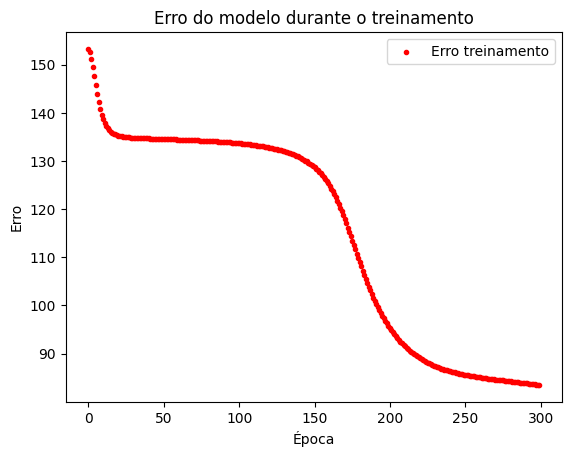

In [34]:
plt.scatter(x_plot, y_plot, color= "red", label= "Erro treinamento", marker= ".")
plt.title("Erro do modelo durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()

O gráfico mostra o compormento da rede neural com o otimizador de descida do gradiente caracterizado por convergir rápido a um mínimo.

### Conclusão 

O modelo funcinou bem em aplicar a descida do gradiente com momento e a aplicação dele foi simples, mostrando a eficiência desse otimizador. Além disso, foi interessante perceber o quão diferente é o comportamento do erro durante o treinamento do modelo, que chega rapidamente a um mínimo e se mantem relativamente constante até chegar em outro mínimo, formando uma espécie de escada.

### Referências

Cassar, Daniel R. Material didático redes neurais do ano de 2025.

INDURAJ. Different Variants of gradient descent. Disponível em: <https://induraj2020.medium.com/different-variants-of-gradient-descent-6854d3118c4c>.

DSA, E. Capítulo 12 - Aprendizado Com a Descida do Gradiente. Disponível em: <https://www.deeplearningbook.com.br/aprendizado-com-a-descida-do-gradiente/>.

WIKIPEDIA CONTRIBUTORS. Gradient descent. Disponível em: <https://en.wikipedia.org/wiki/Gradient_descent>.